# Week 3 — Content-Based Filtering & Hybrid System

This notebook covers:
- **Task 3.1** — TF-IDF content-based filtering
- **Task 3.2** — Hybrid recommender (weighted CF + CBF) with alpha tuning
- **Task 3.3** — Cold-start evaluation & full results table

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import SVD, NMF as SurpriseNMF, Dataset, Reader, accuracy

sys.path.insert(0, '../src')

ratings = pd.read_csv('../data/processed/ratings_clean.csv', parse_dates=['rating_date'])
movies  = pd.read_csv('../data/processed/movies_content.csv')

# Rebuild the same temporal split used in Week 2
ratings_sorted = ratings.sort_values(['userId', 'rating_date'])
test  = ratings_sorted.groupby('userId').tail(1).copy()
train = ratings_sorted.drop(test.index).copy()

print(f"Ratings : {len(ratings):,}  |  Users : {ratings['userId'].nunique()}  |  Movies : {ratings['movieId'].nunique()}")
print(f"Train   : {len(train):,}  |  Test : {len(test):,}")

Ratings : 90,274  |  Users : 610  |  Movies : 3650
Train   : 89,664  |  Test : 610


In [2]:
# Re-train SVD on training set (same hyperparameters as Week 2)
reader   = Reader(rating_scale=(0.5, 5.0))
data     = Dataset.load_from_df(train[['userId', 'movieId', 'rating']], reader)
trainset = data.build_full_trainset()

svd = SVD(n_factors=100, n_epochs=50, lr_all=0.005, reg_all=0.02, random_state=42)
svd.fit(trainset)
print("SVD retrained.")

SVD retrained.


## Task 3.1 — Content-Based Filtering with TF-IDF

**Why TF-IDF?**  
Each movie's `content` field combines genres and user-generated tags. TF-IDF upweights rare, distinctive terms over common ones (e.g. *drama*). Cosine similarity between TF-IDF vectors finds movies that share distinctive vocabulary — which translates to thematic similarity.

**Why not a full item×item matrix?**  
3,650 × 3,650 float32 = ~53 MB — fine here. For ml-25m (62K items) it would be 30 GB. We use row-wise computation to stay memory-safe.

In [3]:
from cbf_model import build_tfidf_matrix, get_similar_items, cbf_recommend_for_user

# Reset movies index so iloc lookups in get_similar_items are reliable
movies = movies.reset_index(drop=True)

tfidf_matrix, tfidf_vectorizer = build_tfidf_matrix(movies, max_features=5000)
print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Non-zero entries    : {tfidf_matrix.nnz:,}")
print(f"Sparsity            : {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}")

TF-IDF matrix shape : (9742, 1450)
Non-zero entries    : 42,360
Sparsity            : 0.9970


In [4]:
# Sanity check — find movies similar to Toy Story (movieId=1)
similar = get_similar_items(1, tfidf_matrix, movies, top_n=10)
result = similar.merge(movies[['movieId', 'title', 'genres']], on='movieId')
print("Movies most similar to Toy Story (movieId=1):")
print(result[['title', 'genres', 'similarity']].to_string(index=False))

Movies most similar to Toy Story (movieId=1):
                                                  title                                      genres  similarity
                                   Bug's Life, A (1998)         Adventure|Animation|Children|Comedy    0.841651
                                     Toy Story 2 (1999) Adventure|Animation|Children|Comedy|Fantasy    0.657978
                                       Wild, The (2006) Adventure|Animation|Children|Comedy|Fantasy    0.522080
                               The Good Dinosaur (2015) Adventure|Animation|Children|Comedy|Fantasy    0.522080
                                            Antz (1998) Adventure|Animation|Children|Comedy|Fantasy    0.522080
                         Tale of Despereaux, The (2008) Adventure|Animation|Children|Comedy|Fantasy    0.522080
                                  Monsters, Inc. (2001) Adventure|Animation|Children|Comedy|Fantasy    0.522080
         Adventures of Rocky and Bullwinkle, The (2000) Ad

In [5]:
# CBF recommendations for an example user
EXAMPLE_USER = train['userId'].iloc[0]

user_history = train[train['userId'] == EXAMPLE_USER].merge(movies[['movieId', 'title']], on='movieId')
print(f"User {EXAMPLE_USER} — top-rated training items:")
print(user_history.nlargest(5, 'rating')[['title', 'rating']].to_string(index=False))

print()
cbf_recs = cbf_recommend_for_user(EXAMPLE_USER, train, tfidf_matrix, movies, top_n=10)
cbf_recs_titled = cbf_recs.merge(movies[['movieId', 'title', 'genres']], on='movieId')
print("CBF recommendations:")
print(cbf_recs_titled[['title', 'genres', 'score']].to_string(index=False))

User 1 — top-rated training items:
                                            title  rating
Star Wars: Episode VI - Return of the Jedi (1983)     5.0
                                     Bambi (1942)     5.0
                                 Gladiator (2000)     5.0
                             Bottle Rocket (1996)     5.0
                           American Beauty (1999)     5.0

CBF recommendations:
                                         title                    genres    score
                   Diamonds Are Forever (1971) Action|Adventure|Thriller 7.451747
                              GoldenEye (1995) Action|Adventure|Thriller 7.451747
Raiders of the Lost Ark: The Adaptation (1989) Action|Adventure|Thriller 7.000000
                            Cliffhanger (1993) Action|Adventure|Thriller 7.000000
                  Living Daylights, The (1987) Action|Adventure|Thriller 7.000000
                 Mission: Impossible II (2000) Action|Adventure|Thriller 7.000000
                     

In [6]:
# Evaluate CBF with sampled Hit Rate@K
# Precompute CBF scores for all eligible test users ONCE, then evaluate at both K=5 and K=10.
import random

rng = random.Random(42)
all_items_test = set(train['movieId'].unique())

cbf_eval_data = []   # list of {test_mid, pool, cbf_map}

print("Precomputing CBF scores for eligible test users...")
for i, (_, row) in enumerate(test.iterrows()):
    uid, test_mid, true_r = row['userId'], row['movieId'], row['rating']
    if true_r < 4.0:
        continue
    user_seen  = set(train[train['userId'] == uid]['movieId'])
    candidates = list(all_items_test - user_seen - {test_mid})
    negatives  = rng.sample(candidates, min(99, len(candidates)))
    pool       = negatives + [test_mid]

    cbf_df  = cbf_recommend_for_user(uid, train, tfidf_matrix, movies,
                                      top_n=len(pool), candidates_per_item=30)
    cbf_map = dict(zip(cbf_df['movieId'], cbf_df['score']))
    cbf_eval_data.append({'test_mid': test_mid, 'pool': pool, 'cbf_map': cbf_map})

    if (i + 1) % 100 == 0:
        print(f"  {i + 1} / {len(test)} users processed")

print(f"Done. Eligible users: {len(cbf_eval_data)}")

# HR@K from precomputed scores — instant
hits5, hits10 = 0, 0
for entry in cbf_eval_data:
    scored = sorted([(entry['cbf_map'].get(m, 0.0), m) for m in entry['pool']], reverse=True)
    top5  = [m for _, m in scored[:5]]
    top10 = [m for _, m in scored[:10]]
    if entry['test_mid'] in top5:  hits5  += 1
    if entry['test_mid'] in top10: hits10 += 1

cbf_hr5  = hits5  / len(cbf_eval_data)
cbf_hr10 = hits10 / len(cbf_eval_data)
print(f"CBF  HR@5 : {cbf_hr5:.4f}")
print(f"CBF  HR@10: {cbf_hr10:.4f}")

Precomputing CBF scores for eligible test users...
  300 / 610 users processed
  400 / 610 users processed
  500 / 610 users processed
  600 / 610 users processed
Done. Eligible users: 360
CBF  HR@5 : 0.0972
CBF  HR@10: 0.1528


## Task 3.2 — Hybrid Recommender

**Strategy:** Weighted linear combination.
```
hybrid_score = α × CF_norm + (1 − α) × CBF_norm
```
Both score sets are min-max normalised to [0, 1] before combining — CF ratings (0.5–5.0) and CBF cosine scores (0–1) are on different scales.

**Alpha grid search** uses a held-out validation split (each user's 2nd-most-recent training rating). The test set is never touched during tuning.

In [7]:
from hybrid import HybridRecommender

hybrid = HybridRecommender(svd, tfidf_matrix, movies, train, alpha=0.7)

recs = hybrid.recommend(EXAMPLE_USER, n=10)
recs_titled = recs.merge(movies[['movieId', 'title', 'genres']], on='movieId')
print(f"Hybrid recommendations for user {EXAMPLE_USER} (alpha=0.7):")
print(recs_titled[['title', 'genres', 'hybrid_score', 'cf_score', 'cbf_score']].to_string(index=False))

Hybrid recommendations for user 1 (alpha=0.7):
                            title                    genres  hybrid_score  cf_score  cbf_score
             Casino Royale (2006) Action|Adventure|Thriller      0.944540  5.000000   7.451747
             Black Panther (2017)   Action|Adventure|Sci-Fi      0.932319  4.766213   9.141749
 7th Voyage of Sinbad, The (1958)  Action|Adventure|Fantasy      0.930071  5.000000   7.010835
Untitled Spider-Man Reboot (2017)  Action|Adventure|Fantasy      0.881734  4.761043   7.645905
        Six-String Samurai (1998)   Action|Adventure|Sci-Fi      0.879610  4.683683   8.263643
          Band of Brothers (2001)          Action|Drama|War      0.879373  4.895533   6.387535
                    Ip Man (2008)          Action|Drama|War      0.876317  4.842314   6.763902
         Bridge Too Far, A (1977)          Action|Drama|War      0.864440  4.779938   6.952250
         Tora! Tora! Tora! (1970)          Action|Drama|War      0.861760  4.770680   6.952250
   

In [8]:
# Validation split: each user's single most recent training rating (mirrors test split)
train_sorted  = train.sort_values(['userId', 'rating_date'])
val_set       = train_sorted.groupby('userId').tail(1).copy()   # 1 per user = 610 rows
train_reduced = train_sorted.drop(val_set.index).copy()

print(f"Train reduced : {len(train_reduced):,}")
print(f"Val           : {len(val_set):,}  (1 per user)")

# Retrain SVD on reduced train
data_r     = Dataset.load_from_df(train_reduced[['userId', 'movieId', 'rating']], reader)
trainset_r = data_r.build_full_trainset()
svd_r = SVD(n_factors=100, n_epochs=50, lr_all=0.005, reg_all=0.02, random_state=42)
svd_r.fit(trainset_r)
print("SVD retrained on reduced train.")

Train reduced : 89,054
Val           : 610  (1 per user)
SVD retrained on reduced train.


In [9]:
# Precompute CF and CBF scores for every eligible validation user ONCE.
# Alpha tuning then becomes a cheap weighted-sum over these cached scores.
import random

rng_val    = random.Random(42)
all_items_val = set(train_reduced['movieId'].unique())

val_precomputed = []   # list of {test_mid, pool, cf_norm, cbf_norm}

def minmax(d):
    vals = np.array(list(d.values()), dtype=float)
    lo, hi = vals.min(), vals.max()
    if hi == lo:
        return {k: 0.0 for k in d}
    return {k: (v - lo) / (hi - lo) for k, v in d.items()}

print("Precomputing CF + CBF scores for validation users (runs once)...")
for i, (_, row) in enumerate(val_set.iterrows()):
    uid, test_mid, true_r = row['userId'], row['movieId'], row['rating']
    if true_r < 4.0:
        continue
    user_seen  = set(train_reduced[train_reduced['userId'] == uid]['movieId'])
    candidates = list(all_items_val - user_seen - {test_mid})
    if len(candidates) < 99:
        continue
    negatives = rng_val.sample(candidates, 99)
    pool      = negatives + [test_mid]

    # CF scores (100 SVD calls per user instead of 3000)
    cf_raw  = {m: svd_r.predict(uid, m).est for m in pool}

    # CBF scores
    cbf_df  = cbf_recommend_for_user(uid, train_reduced, tfidf_matrix, movies,
                                      top_n=len(pool), candidates_per_item=30)
    cbf_raw = {m: dict(zip(cbf_df['movieId'], cbf_df['score'])).get(m, 0.0) for m in pool}

    val_precomputed.append({
        'test_mid': test_mid,
        'pool'    : pool,
        'cf_norm' : minmax(cf_raw),
        'cbf_norm': minmax(cbf_raw),
    })

    if (i + 1) % 100 == 0:
        print(f"  {i + 1} / {len(val_set)} processed")

print(f"Done. Eligible val users: {len(val_precomputed)}")

Precomputing CF + CBF scores for validation users (runs once)...
  200 / 610 processed
  400 / 610 processed
  600 / 610 processed
Done. Eligible val users: 355


In [10]:
# Alpha grid search — pure arithmetic over precomputed scores, runs in milliseconds per alpha
best_alpha, best_hr10 = 0.7, 0.0
alpha_results = []

for alpha in [0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    hits = 0
    for entry in val_precomputed:
        test_mid = entry['test_mid']
        scored = sorted(
            [(alpha * entry['cf_norm'][m] + (1 - alpha) * entry['cbf_norm'][m], m)
             for m in entry['pool']],
            reverse=True
        )
        if test_mid in [m for _, m in scored[:10]]:
            hits += 1
    hr10 = hits / len(val_precomputed)
    alpha_results.append((alpha, hr10))
    print(f"  alpha={alpha:.1f}  HR@10={hr10:.4f}")
    if hr10 > best_hr10:
        best_alpha, best_hr10 = alpha, hr10

print(f"\nBest alpha: {best_alpha}  (val HR@10={best_hr10:.4f})")

  alpha=0.3  HR@10=0.2901
  alpha=0.5  HR@10=0.2901
  alpha=0.6  HR@10=0.2901
  alpha=0.7  HR@10=0.2873
  alpha=0.8  HR@10=0.2930
  alpha=0.9  HR@10=0.2817
  alpha=1.0  HR@10=0.2732

Best alpha: 0.8  (val HR@10=0.2930)


In [11]:
# Final hybrid evaluation on the held-out test set.
# Same precompute approach: score 100 items per user once, evaluate HR@5 and HR@10.
import random

rng_test   = random.Random(42)
all_items_t = set(train['movieId'].unique())
test_precomputed = []

print("Precomputing CF + CBF scores for test users (runs once)...")
for i, (_, row) in enumerate(test.iterrows()):
    uid, test_mid, true_r = row['userId'], row['movieId'], row['rating']
    if true_r < 4.0:
        continue
    user_seen  = set(train[train['userId'] == uid]['movieId'])
    candidates = list(all_items_t - user_seen - {test_mid})
    negatives  = rng_test.sample(candidates, min(99, len(candidates)))
    pool       = negatives + [test_mid]

    cf_raw  = {m: svd.predict(uid, m).est for m in pool}
    cbf_df  = cbf_recommend_for_user(uid, train, tfidf_matrix, movies,
                                      top_n=len(pool), candidates_per_item=30)
    cbf_raw = {m: dict(zip(cbf_df['movieId'], cbf_df['score'])).get(m, 0.0) for m in pool}

    test_precomputed.append({
        'test_mid': test_mid,
        'pool'    : pool,
        'cf_norm' : minmax(cf_raw),
        'cbf_norm': minmax(cbf_raw),
    })

    if (i + 1) % 100 == 0:
        print(f"  {i + 1} / {len(test)} processed")

print(f"Done. Eligible test users: {len(test_precomputed)}")

# Evaluate with best alpha — instant
hits5, hits10 = 0, 0
for entry in test_precomputed:
    test_mid = entry['test_mid']
    scored = sorted(
        [(best_alpha * entry['cf_norm'][m] + (1 - best_alpha) * entry['cbf_norm'][m], m)
         for m in entry['pool']],
        reverse=True
    )
    if test_mid in [m for _, m in scored[:5]]:  hits5  += 1
    if test_mid in [m for _, m in scored[:10]]: hits10 += 1

hybrid_hr5  = hits5  / len(test_precomputed)
hybrid_hr10 = hits10 / len(test_precomputed)
print(f"Hybrid (alpha={best_alpha})  HR@5={hybrid_hr5:.4f}  HR@10={hybrid_hr10:.4f}")

Precomputing CF + CBF scores for test users (runs once)...
  300 / 610 processed
  400 / 610 processed
  500 / 610 processed
  600 / 610 processed
Done. Eligible test users: 360
Hybrid (alpha=0.8)  HR@5=0.1889  HR@10=0.2639


## Task 3.3 — Cold-Start Analysis & Full Results Table

**Cold-start** = users with few training ratings. We expect:
- Pure CF (SVD) degrades for cold users — sparse neighbourhoods
- CBF degrades less — only needs 1–2 seed items
- Hybrid with cold-start fallback should match or beat pure CF for cold users

In [12]:
# Segment users by training activity
user_train_counts = train.groupby('userId').size()

cold_users   = user_train_counts[user_train_counts < 20].index
mid_users    = user_train_counts[(user_train_counts >= 20) & (user_train_counts < 100)].index
active_users = user_train_counts[user_train_counts >= 100].index

print(f"Cold   (<20 ratings) : {len(cold_users)} users")
print(f"Mid   (20-99)        : {len(mid_users)} users")
print(f"Active (100+)        : {len(active_users)} users")

test_cold   = test[test['userId'].isin(cold_users)]
test_active = test[test['userId'].isin(active_users)]
print(f"\nTest rows — cold: {len(test_cold)}  active: {len(test_active)}")

Cold   (<20 ratings) : 27 users
Mid   (20-99)        : 348 users
Active (100+)        : 235 users

Test rows — cold: 27  active: 235


In [13]:
# SVD HR@10 by segment — reuse precomputed test scores for speed
def segment_hr10_from_precomputed(precomputed_list, user_segment_ids, test_df):
    """Filter precomputed entries to a user segment and compute HR@10 using CF scores only."""
    seg_uids = set(user_segment_ids)
    seg_test = test_df[test_df['userId'].isin(seg_uids)]
    seg_mids = set(seg_test['movieId'])

    hits, n_el = 0, 0
    for entry in precomputed_list:
        if entry['test_mid'] not in seg_mids:
            continue
        scored = sorted(entry['cf_norm'].items(), key=lambda x: x[1], reverse=True)
        if entry['test_mid'] in [m for m, _ in scored[:10]]:
            hits += 1
        n_el += 1
    return hits / n_el if n_el > 0 else 0.0

svd_cold   = segment_hr10_from_precomputed(test_precomputed, cold_users,   test)
svd_active = segment_hr10_from_precomputed(test_precomputed, active_users, test)
print(f"SVD HR@10 — cold users  : {svd_cold:.4f}")
print(f"SVD HR@10 — active users: {svd_active:.4f}")

SVD HR@10 — cold users  : 0.2500
SVD HR@10 — active users: 0.2561


In [14]:
# Week 2 results (from collaborative_filtering notebook)
svd_hr5_w2, svd_hr10_w2 = 0.1833, 0.2583
nmf_hr5_w2, nmf_hr10_w2 = 0.1222, 0.2139

print("=" * 65)
print(f"{'Model':<28} {'HR@5':>7} {'HR@10':>7}")
print("-" * 65)
print(f"{'SVD (k=100)':<28} {svd_hr5_w2:>7.4f} {svd_hr10_w2:>7.4f}")
print(f"{'NMF (k=50)':<28} {nmf_hr5_w2:>7.4f} {nmf_hr10_w2:>7.4f}")
print(f"{'Content-Based (TF-IDF)':<28} {cbf_hr5:>7.4f} {cbf_hr10:>7.4f}")
print(f"{'Hybrid (alpha=' + str(best_alpha) + ')':<28} {hybrid_hr5:>7.4f} {hybrid_hr10:>7.4f}")
print("=" * 65)
print()
print("Cold-start segment (SVD):")
print(f"  Cold user HR@10  : {svd_cold:.4f}")
print(f"  Active user HR@10: {svd_active:.4f}")

Model                           HR@5   HR@10
-----------------------------------------------------------------
SVD (k=100)                   0.1833  0.2583
NMF (k=50)                    0.1222  0.2139
Content-Based (TF-IDF)        0.0972  0.1528
Hybrid (alpha=0.8)            0.1889  0.2639

Cold-start segment (SVD):
  Cold user HR@10  : 0.2500
  Active user HR@10: 0.2561


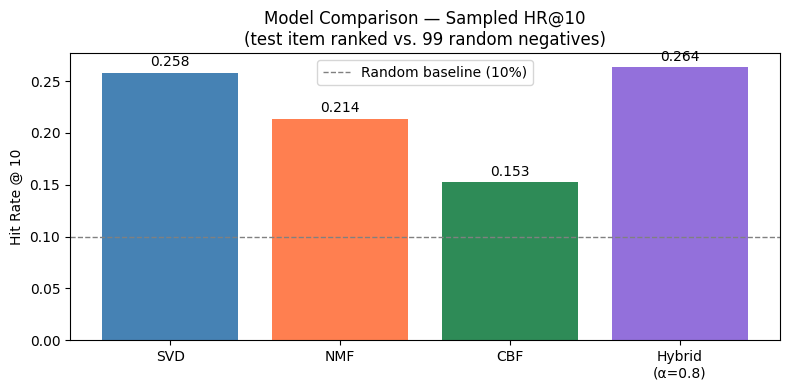

Saved to data/processed/viz_model_comparison.png


In [15]:
# Visualise HR@10 comparison
models    = ['SVD', 'NMF', 'CBF', f'Hybrid\n(α={best_alpha})']
hr10_vals = [svd_hr10_w2, nmf_hr10_w2, cbf_hr10, hybrid_hr10]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(models, hr10_vals, color=['steelblue', 'coral', 'seagreen', 'mediumpurple'])
ax.axhline(0.10, color='grey', linestyle='--', linewidth=1, label='Random baseline (10%)')
ax.set_ylabel('Hit Rate @ 10')
ax.set_title('Model Comparison — Sampled HR@10\n(test item ranked vs. 99 random negatives)')
ax.legend()
for bar, val in zip(bars, hr10_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003, f'{val:.3f}',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/viz_model_comparison.png', dpi=120)
plt.show()
print("Saved to data/processed/viz_model_comparison.png")